
#  Priors 


In [1]:
# --- Output folder override
from pathlib import Path
FIG_DIR = Path(r"C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"[setup] Figures will be saved to: {FIG_DIR}")


[setup] Figures will be saved to: C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\figures


In [2]:

# --- Config (edit as needed) ---
PRED_Q_LO = 0.10      # predictive lower quantile (fraction, e.g., 0.10)
PRED_Q_HI = 0.90      # predictive upper quantile (fraction, e.g., 0.90)
ROLL_WINDOW = None    # e.g., '7D' to show a rolling mean of AF (optional)
MAX_SITES = None      # limit plotting to first N sites (None = all)
MAX_MUTS  = None      # limit plotting to first N mutations overall (None = all)
MAX_PAIRS = None      # limit (site,mutation) detail pages (None = all)
SAVE_PNG  = True
SAVE_PDF  = True
DPI       = 150
PAGESIZE  = (12, 8)   # width, height in inches for figures

# --- Auto-detect repo root ---
import os
from pathlib import Path

def find_repo_root(start=None):
    p = Path(start or os.getcwd()).resolve()
    # Walk up looking for 'results/priors/priors_full_detail.csv' or 'results' / 'configs'
    while True:
        if (p/'results'/'priors'/'priors_full_detail.csv').exists():
            return p
        if (p/'.git').exists() or (p/'configs').exists():
            root_guess = p
        if p.parent == p:
            break
        p = p.parent
    # Fallback: current working directory
    return Path(start or os.getcwd()).resolve()

REPO_ROOT = find_repo_root()
PRIOR_DIR = REPO_ROOT / 'results' / 'priors'
FIG_DIR   = FIG_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"[info] REPO_ROOT = {REPO_ROOT}")
print(f"[info] Using results in {PRIOR_DIR}")
print(f"[info] Figures -> {FIG_DIR}")

# --- Imports & Styles (no-TeX) ---
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MaxNLocator

import seaborn as sns
import scienceplots  # style only
import colorcet as cc
import cmocean
from palettable.colorbrewer.qualitative import Set3_12
from palettable.cartocolors.qualitative import Safe_10

# Use SciencePlots *without LaTeX*
plt.style.use(['science', 'no-latex', 'bright'])

# Nice defaults; no TeX anywhere.
mpl.rcParams.update({
    "axes.unicode_minus": False,
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "savefig.bbox": "tight",
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

sns.set_theme(style="whitegrid", context="notebook")
# Distinct categorical palette for many series
sns.set_palette(sns.color_palette(cc.glasbey[:20]))

plt.ioff()  # do not try to display figures inline while saving lots of files


[info] REPO_ROOT = C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting
[info] Using results in C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors
[info] Figures -> C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\figures


In [3]:
import pandas as pd

path = PRIOR_DIR / "priors_hyperparams.csv"

# Read with tolerant parser
df = pd.read_csv(
    path,
    header=None,
    engine="python",       # fallback parser that tolerates irregular fields
    on_bad_lines="skip",   # skip lines that break field count
)

# Keep only the first 5 columns
df = df.iloc[:, :5]
df.columns = ["mutation", "mu", "kappa", "alpha", "beta"]

# Save clean version
df.to_csv(path, index=False)
print("[ok] Cleaned priors_hyperparams.csv — now has shape", df.shape)



[ok] Cleaned priors_hyperparams.csv — now has shape (64, 5)


In [4]:

# ---- Required ----
p_full = PRIOR_DIR / 'priors_full_detail.csv'
assert p_full.exists(), f"Required file not found: {p_full}"

# Windows-safe filename sanitizer
import re
_INVALID = re.compile(r'[<>:"/\\|?*\x00-\x1F]')
def safe_fname(x: str, maxlen: int = 200) -> str:
    s = str(x)
    s = _INVALID.sub("_", s)
    s = s.replace(" ", "_").rstrip(". ").strip()
    return s[:maxlen] if maxlen else s

df = pd.read_csv(p_full, parse_dates=['date'])
# Normalize column names
df.rename(columns={'kappa_use':'kappa_t'}, inplace=True)
if 'af' not in df.columns:
    df['af'] = np.where(df['coverage']>0, df['count']/df['coverage'].clip(lower=1), np.nan)

# ---- Optionals ----
def _read_csv_opt(name, parse_dates=None):
    path = PRIOR_DIR / name
    return pd.read_csv(path, parse_dates=parse_dates) if path.exists() else None

hyper = _read_csv_opt('priors_hyperparams.csv')
gts   = _read_csv_opt('detail_global_timeseries.csv', parse_dates=['date'])
shifts= _read_csv_opt('time_shifts.csv')
eb    = _read_csv_opt('eb_population_prior.csv')
proc  = _read_csv_opt('process_noise_by_mutation.csv')

print('[info] Loaded: priors_full_detail.csv')
print(f"[info] Also found: "
      f"hyper={hyper is not None}, global_ts={gts is not None}, time_shifts={shifts is not None}, "
      f"eb={eb is not None}, process_noise={proc is not None}")


[info] Loaded: priors_full_detail.csv
[info] Also found: hyper=True, global_ts=True, time_shifts=False, eb=True, process_noise=False


In [5]:
import numpy as np
from scipy.stats import betabinom
from scipy.special import betaincinv

# ==========================================================
# Fast predictive bands + PIT computation
# ==========================================================
def add_predictive_betabinom_metrics(df, q_lo=0.10, q_hi=0.90):
    n  = df["coverage"].to_numpy(np.int64, copy=False)
    y  = df["count"].to_numpy(np.int64, copy=False)
    mu = np.clip(df["mu_t"].to_numpy(np.float64, copy=False), 1e-9, 1 - 1e-9)
    k  = np.clip(df["kappa_t"].to_numpy(np.float64, copy=False), 1e-8, 1e9)
    mask = n > 0

    # Beta parameters
    a, b = mu * k, (1 - mu) * k

    # Predictive bands using Beta quantiles (fast approximation)
    lo = np.full_like(mu, np.nan, dtype=float)
    hi = np.full_like(mu, np.nan, dtype=float)
    if np.any(mask):
        p_lo = betaincinv(a[mask], b[mask], q_lo)
        p_hi = betaincinv(a[mask], b[mask], q_hi)
        lo[mask] = np.floor(n[mask] * p_lo)
        hi[mask] = np.ceil(n[mask] * p_hi)

    # Convert to AF scale
    n_f = n.astype(float)
    df["pred_lo_ct"] = lo
    df["pred_hi_ct"] = hi
    df["pred_lo_af"] = np.divide(lo, n_f, out=np.full_like(lo, np.nan), where=mask)
    df["pred_hi_af"] = np.divide(hi, n_f, out=np.full_like(hi, np.nan), where=mask)

    # Vectorized PIT (mid-P)
    Fy  = betabinom.cdf(y, n, a, b)
    pmf = betabinom.pmf(y, n, a, b)
    u = np.clip(Fy - 0.5 * pmf, 0, 1)
    u[~np.isfinite(u)] = 0.5
    df["pit_mid"] = u

    # Outlier flag
    af = df["af"].to_numpy(np.float64, copy=False)
    outlier = (af < df["pred_lo_af"]) | (af > df["pred_hi_af"])
    df["outlier"] = np.where(np.isfinite(af), outlier, False)

    print(f"[info] Derived predictive bands and PIT for {len(df):,} rows.")
    return df

df = add_predictive_betabinom_metrics(df, q_lo=PRED_Q_LO, q_hi=PRED_Q_HI)



[info] Derived predictive bands and PIT for 82,538 rows.


In [6]:

# Apply optional limits to cut down plots if desired
sites_all = df['site_id'].dropna().astype(str).unique().tolist()
muts_all  = df['mutation'].dropna().astype(str).unique().tolist()

sites_sel = sites_all[:MAX_SITES] if isinstance(MAX_SITES, int) else sites_all
muts_sel  = muts_all[:MAX_MUTS]   if isinstance(MAX_MUTS, int)   else muts_all

df_sel = df[df['site_id'].isin(sites_sel) & df['mutation'].isin(muts_sel)].copy()

print(f"[info] Sites: {len(sites_sel)} of {len(sites_all)}; Mutations: {len(muts_sel)} of {len(muts_all)}")


[info] Sites: 6 of 6; Mutations: 62 of 62


In [7]:

from matplotlib.gridspec import GridSpec

def _ax_format_time(ax, title=None):
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, prune=None))
    ax.set_xlabel('Date')
    ax.set_ylabel('Allele frequency')
    if title:
        ax.set_title(title, fontsize=11)

def plot_series_panel(ax, d, title=None):
    # shaded predictive band (AF)
    ax.fill_between(d['date'], d['pred_lo_af'], d['pred_hi_af'], alpha=0.2, label=f'Pred {int((PRED_Q_HI-PRED_Q_LO)*100)}% AF')
    # posterior median mu(t)
    ax.plot(d['date'], d['mu_t'], linewidth=2, label='μ(t)')
    # optional CI for μ, if present
    if {'mu_lo','mu_hi'}.issubset(d.columns):
        ax.fill_between(d['date'], d['mu_lo'], d['mu_hi'], alpha=0.15, label='μ 95% CI')
    # observations
    sz = np.clip(np.sqrt(d['coverage'].fillna(0))/4.0, 3, 16)  # marker size ~ sqrt(coverage)
    ax.scatter(d['date'], d['af'], s=sz, alpha=0.65, label='Observed AF')
    # outliers
    out = d[d['outlier']]
    if not out.empty:
        ax.scatter(out['date'], out['af'], s=sz[out.index], facecolors='none', edgecolors='r', linewidths=1.2, label='Outlier')
    _ax_format_time(ax, title=title)
    ax.set_ylim(-0.03, 1.03)
    ax.legend(loc='best', fontsize=8, frameon=False)

def plot_pair_detail_page(fig, d, site_id, mutation):
    # page layout: 2x2
    gs = GridSpec(2, 2, figure=fig)
    ax1 = fig.add_subplot(gs[0, :])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[1, 1])

    # top: time series
    plot_series_panel(ax1, d, title=f"{site_id} — {mutation} (series)")
    # bottom-left: counts vs predictive band
    ax2.fill_between(d['date'], d['pred_lo_ct'], d['pred_hi_ct'], alpha=0.2)
    ax2.plot(d['date'], d['count'], linewidth=1.5)
    ax2.set_title('Counts vs Pred band')
    ax2.set_ylabel('Count')
    ax2.xaxis.set_major_locator(MaxNLocator(nbins=6))
    # bottom-right: PIT histogram
    u = d['pit_mid'].dropna().to_numpy()
    ax3.hist(u, bins=20, range=(0,1), density=True)
    ax3.set_title('PIT (mid-P)')
    ax3.set_xlabel('u')
    ax3.set_ylabel('density')


In [8]:

# ---------- Sites dashboard ----------
site_pages = FIG_DIR / 'sites'
site_pages.mkdir(parents=True, exist_ok=True)

pdf_sites_path = FIG_DIR / 'sites_dashboard.pdf' if SAVE_PDF else None
pdf_sites = PdfPages(pdf_sites_path) if SAVE_PDF else None

for s in sites_sel:
    dsite = df_sel[df_sel['site_id'] == s]
    muts = sorted(dsite['mutation'].unique().tolist())
    if not muts:
        continue

    ncols = 3
    nrows = int(np.ceil(len(muts) / ncols))

    fig = plt.figure(figsize=(PAGESIZE[0], max(PAGESIZE[1], 3 + 3 * nrows)))
    gs = GridSpec(nrows, ncols, figure=fig)

    for i, m in enumerate(muts):
        r, c = divmod(i, ncols)
        ax = fig.add_subplot(gs[r, c])
        d = dsite[dsite['mutation'] == m].sort_values('date')
        plot_series_panel(ax, d, title=str(m))

    fig.suptitle(f"Site: {s}", fontsize=14, y=0.995)
    fig.tight_layout(rect=[0, 0.01, 1, 0.97])

    if SAVE_PNG:
        out = site_pages / f"site_{safe_fname(s)}.png"
        fig.savefig(out, dpi=DPI, bbox_inches="tight")

    if pdf_sites is not None:
        pdf_sites.savefig(fig)

    plt.close(fig)

if pdf_sites is not None:
    pdf_sites.close()
    print(f"[info] Wrote {pdf_sites_path}")

print(f"[info] Per-site PNGs -> {site_pages}")


[info] Wrote C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\figures\sites_dashboard.pdf
[info] Per-site PNGs -> C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\figures\sites


In [9]:

# ---------- Mutations dashboard ----------
mut_pages = FIG_DIR / 'mutations'
mut_pages.mkdir(parents=True, exist_ok=True)

pdf_muts_path = FIG_DIR / 'mutations_dashboard.pdf' if SAVE_PDF else None
pdf_muts = PdfPages(pdf_muts_path) if SAVE_PDF else None

for m in muts_sel:
    dmut = df_sel[df_sel['mutation']==m]
    sites = sorted(dmut['site_id'].unique().tolist())
    if not sites:
        continue
    ncols = 3
    nrows = int(np.ceil(len(sites) / ncols))
    fig = plt.figure(figsize=(PAGESIZE[0], max(PAGESIZE[1], 3 + 3*nrows)))
    gs = GridSpec(nrows, ncols, figure=fig)
    for i, s in enumerate(sites):
        r, c = divmod(i, ncols)
        ax = fig.add_subplot(gs[r, c])
        d = dmut[dmut['site_id']==s].sort_values('date')
        plot_series_panel(ax, d, title=str(s))
    fig.suptitle(f"Mutation: {m}", fontsize=14, y=0.995)
    fig.tight_layout(rect=[0, 0.01, 1, 0.97])

    if SAVE_PNG:
        out = mut_pages / f"mutation_{safe_fname(m)}.png"
        fig.savefig(out, dpi=DPI, bbox_inches="tight")

    if pdf_muts is not None:
        pdf_muts.savefig(fig)

    plt.close(fig)

if pdf_muts is not None:
    pdf_muts.close()
    print(f"[info] Wrote {pdf_muts_path}")

print(f"[info] Per-mutation PNGs -> {mut_pages}")


[info] Wrote C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\figures\mutations_dashboard.pdf
[info] Per-mutation PNGs -> C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\figures\mutations


In [10]:

# ---------- Pair detail pages ----------
pair_pages = FIG_DIR / 'pairs'
pair_pages.mkdir(parents=True, exist_ok=True)

pairs = (df_sel[['site_id','mutation']]
         .drop_duplicates()
         .sort_values(['site_id','mutation'])
         .to_records(index=False))

if isinstance(MAX_PAIRS, int):
    pairs = pairs[:MAX_PAIRS]

pdf_pairs_path = FIG_DIR / 'pair_details.pdf' if SAVE_PDF else None
pdf_pairs = PdfPages(pdf_pairs_path) if SAVE_PDF else None

for s, m in pairs:
    d = df_sel[(df_sel['site_id']==s) & (df_sel['mutation']==m)].sort_values('date')
    if d.empty:
        continue
    fig = plt.figure(figsize=(PAGESIZE[0], PAGESIZE[1]))
    plot_pair_detail_page(fig, d, s, m)
    fig.tight_layout()

    if SAVE_PNG:
        out = pair_pages / f"pair_{safe_fname(s)}__{safe_fname(m)}.png"
        fig.savefig(out, dpi=DPI, bbox_inches="tight")
    if pdf_pairs is not None:
        pdf_pairs.savefig(fig)
    plt.close(fig)

if pdf_pairs is not None:
    pdf_pairs.close()
    print(f"[info] Wrote {pdf_pairs_path}")

print(f"[info] Pair PNGs -> {pair_pages}")


[info] Wrote C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\figures\pair_details.pdf
[info] Pair PNGs -> C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\figures\pairs


KS p-value vs Uniform(0,1): 0


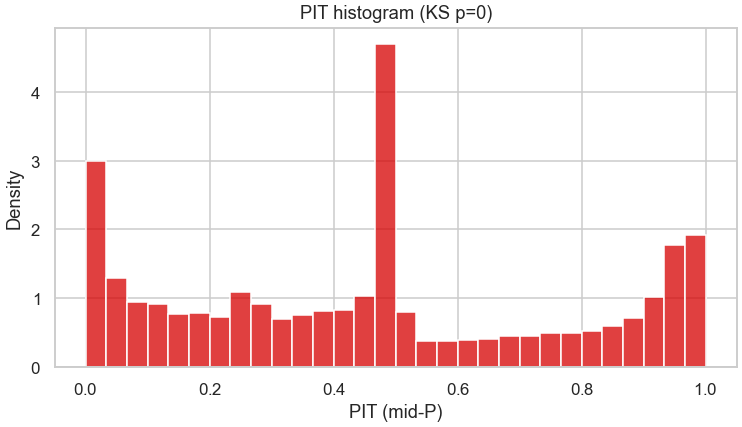

[info] Global summaries -> C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\figures\global


In [11]:
# Minimal imports for the KS check + plot
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # remove if you don't use seaborn
from scipy.stats import kstest  # <-- this fixes the NameError

# u = your PIT array; example pulling from df:
u = np.asarray(df["pit_mid"].dropna().to_numpy(float))
u = np.clip(u, 0.0, 1.0)

ks_p = kstest(u, 'uniform').pvalue
print(f"KS p-value vs Uniform(0,1): {ks_p:.6g}")

fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(u, bins=30, stat="density", binrange=(0,1), ax=ax)
ax.set(xlabel="PIT (mid-P)", ylabel="Density", title=f"PIT histogram (KS p={ks_p:.3g})")
plt.show()



# ---------- Global summaries ----------
glob_dir = FIG_DIR / 'global'
glob_dir.mkdir(parents=True, exist_ok=True)

# Distribution plots: mu_t and kappa_t across all rows
fig, ax = plt.subplots(figsize=(10,4))
sns.histplot(df['mu_t'].dropna(), bins=50, stat="density", ax=ax)
ax.set_title('Distribution of μ(t) across rows')
ax.set_xlabel('μ')
ax.set_ylabel('density')
if SAVE_PNG: fig.savefig(glob_dir / 'mu_distribution.png', dpi=DPI); plt.close(fig)

fig, ax = plt.subplots(figsize=(10,4))
sns.histplot(df['kappa_t'].dropna(), bins=50, stat="density", ax=ax)
ax.set_title('Distribution of κ across rows')
ax.set_xlabel('κ')
ax.set_ylabel('density')
if SAVE_PNG: fig.savefig(glob_dir / 'kappa_distribution.png', dpi=DPI); plt.close(fig)

# Outlier rate by mutation
out_rate = (df.groupby('mutation')['outlier'].mean()
            .sort_values(ascending=False)
            .reset_index(name='outlier_rate'))
fig, ax = plt.subplots(figsize=(min(14, 4 + 0.2*len(out_rate)), 4))
sns.barplot(data=out_rate, x='mutation', y='outlier_rate', ax=ax)
ax.set_title('Outlier rate by mutation')
ax.set_ylabel('rate')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=60)
if SAVE_PNG: fig.savefig(glob_dir / 'outlier_rate_by_mutation.png', dpi=DPI); plt.close(fig)

# Rows per day
rows_per_date = df.groupby('date').size().reset_index(name='n')
fig, ax = plt.subplots(figsize=(12,4))
ax.bar(rows_per_date['date'], rows_per_date['n'], width=1.0)
ax.set_title('Number of rows per day')
ax.set_ylabel('rows')
ax.xaxis.set_major_locator(MaxNLocator(nbins=8))
if SAVE_PNG: fig.savefig(glob_dir / 'rows_per_day.png', dpi=DPI); plt.close(fig)

# PIT histogram overall + KS test against Uniform(0,1)
u = df['pit_mid'].dropna().to_numpy()
ks_p = float('nan')
if u.size > 0:
    ks_p = kstest(u, 'uniform').pvalue
fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(u, bins=30, stat="density", binrange=(0,1), ax=ax)
ax.set_title(f'Global PIT (mid-P) — KS p={ks_p:.3g}')
ax.set_xlabel('u')
ax.set_ylabel('density')
if SAVE_PNG: fig.savefig(glob_dir / 'pit_hist_global.png', dpi=DPI); plt.close(fig)

print(f"[info] Global summaries -> {glob_dir}")


In [12]:

# ---------- Global μ(t) per mutation ----------
gmt_dir = FIG_DIR / 'global_ts'
gmt_dir.mkdir(parents=True, exist_ok=True)

if gts is not None and {'date','mutation','mu_t'}.issubset(gts.columns):
    gsrc = gts.copy()
else:
    # Fallback: unweighted mean μ per date, per mutation computed from priors_full_detail
    gsrc = (df.groupby(['date','mutation'], as_index=False)
              .agg(mu_t=('mu_t','mean')))

for m in muts_sel:
    d = gsrc[gsrc['mutation']==m].sort_values('date')
    if d.empty:
        continue
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(d['date'], d['mu_t'], linewidth=2)
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(f'Global μ(t) — {m}')
    ax.set_xlabel('Date'); ax.set_ylabel('μ')
    ax.xaxis.set_major_locator(MaxNLocator(nbins=8))
    if SAVE_PNG:
        out = gmt_dir / f'global_mu_{safe_fname(m)}.png'
        fig.savefig(out, dpi=DPI, bbox_inches="tight")
    plt.close(fig)

print(f"[info] Global μ(t) lines -> {gmt_dir}")


[info] Global μ(t) lines -> C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\figures\global_ts


In [13]:

# ---------- Coverage diagnostics by coverage decile ----------
cov = df[['coverage','count','pred_lo_ct','pred_hi_ct']].dropna()
cov = cov[cov['coverage']>0].copy()
if not cov.empty:
    cov['tile'] = pd.qcut(cov['coverage'], q=10, duplicates='drop')
    cov['covered'] = (cov['count'] >= cov['pred_lo_ct']) & (cov['count'] <= cov['pred_hi_ct'])
    cov_rate = cov.groupby('tile')['covered'].mean().reset_index(name='coverage_rate')

    fig, ax = plt.subplots(figsize=(10,4))
    sns.barplot(data=cov_rate, x='tile', y='coverage_rate', ax=ax)
    ax.set_title(f'Predictive coverage (counts) by coverage decile — target {(PRED_Q_HI-PRED_Q_LO):.0%}')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    if SAVE_PNG: fig.savefig(FIG_DIR / 'coverage_by_coverage_decile.png', dpi=DPI); plt.close(fig)


C:\Users\osoom\AppData\Local\Temp\ipykernel_39200\3949721743.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cov_rate = cov.groupby('tile')['covered'].mean().reset_index(name='coverage_rate')


In [14]:
import numpy as np
import pandas as pd
from scipy.stats import kstest
import matplotlib.pyplot as plt
import seaborn as sns

def pit_ks_by_site(df, min_n=20):
    s = (df.loc[:, ["site_id", "pit_mid"]]
           .assign(pit_mid=pd.to_numeric(df["pit_mid"], errors="coerce"))
           .dropna(subset=["pit_mid"]))
    if s.empty:
        return pd.DataFrame(columns=["site_id", "ks_p", "n"])

    def _ks(u):
        u = np.clip(np.asarray(u, float), 0.0, 1.0)
        return kstest(u, "uniform").pvalue

    out = (s.groupby("site_id")["pit_mid"]
             .agg(n="size", ks_p=_ks)
             .reset_index())
    out = out[out["n"] >= min_n].sort_values("ks_p", ascending=True)
    return out

# ---- Run + plot ----
ks_df = pit_ks_by_site(df_sel, min_n=20)

if ks_df.empty:
    # Diagnostics to see why it's empty
    print("[diag] unique sites in df_sel:", df_sel["site_id"].nunique())
    print("[diag] top counts of finite PIT per site:\n",
          (pd.to_numeric(df_sel["pit_mid"], errors="coerce")
             .groupby(df_sel["site_id"]).apply(lambda s: s.notna().sum())
             .sort_values(ascending=False)
             .head(10)))
else:
    fig, ax = plt.subplots(figsize=(min(14, 4 + 0.15*len(ks_df)), 5))
    sns.barplot(data=ks_df, x="site_id", y="ks_p", ax=ax)
    ax.set_title("PIT KS p-value by site (higher is better)")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=60)
    if SAVE_PNG:
        fig.savefig(FIG_DIR / "pit_ks_by_site.png", dpi=DPI)
        plt.close(fig)



In [15]:

# ---------- κ vs μ scatter ----------
samp = df[['mu_t','kappa_t']].dropna()
if len(samp) > 200000:
    samp = samp.sample(200000, random_state=123)

fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(samp['mu_t'], samp['kappa_t'], s=6, alpha=0.3)
ax.set_xlabel('μ'); ax.set_ylabel('κ')
ax.set_title('Scatter of κ vs μ')
if SAVE_PNG: fig.savefig(FIG_DIR / 'scatter_kappa_vs_mu.png', dpi=DPI); plt.close(fig)


In [16]:

# ---------- Process noise scatter ) ----------
if proc is not None and {'q_LL_hat','q_b_hat'}.issubset(proc.columns):
    x = np.clip(proc['q_LL_hat'].to_numpy(dtype=float), 1e-12, None)
    y = np.clip(proc['q_b_hat'].to_numpy(dtype=float), 1e-12, None)
    fig, ax = plt.subplots(figsize=(5,5))
    ax.scatter(x, y, s=16, alpha=0.7)
    # Only log-scale if strictly positive
    if np.all(x > 0) and np.all(y > 0):
        ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('q_LL_hat'); ax.set_ylabel('q_b_hat')
    ax.set_title('Per-mutation process noise')
    if SAVE_PNG: fig.savefig(FIG_DIR / 'process_noise_scatter.png', dpi=DPI); plt.close(fig)

    # Marginal histograms (log10)
    fig, ax = plt.subplots(figsize=(6,4))
    ax.hist(np.log10(x), bins=40, alpha=0.9)
    ax.set_xlabel('log10 q_LL_hat'); ax.set_ylabel('Count'); ax.set_title('Distribution of q_LL_hat')
    if SAVE_PNG: fig.savefig(FIG_DIR / 'q_LL_hist_log10.png', dpi=DPI); plt.close(fig)

    fig, ax = plt.subplots(figsize=(6,4))
    ax.hist(np.log10(y), bins=40, alpha=0.9)
    ax.set_xlabel('log10 q_b_hat'); ax.set_ylabel('Count'); ax.set_title('Distribution of q_b_hat')
    if SAVE_PNG: fig.savefig(FIG_DIR / 'q_b_hist_log10.png', dpi=DPI); plt.close(fig)


In [5]:
# ===================== PRIORS: FULL METRICS PACK (CSV-only, Methods-ready) =====================
# Metrics -> results/priors/metric/
# Reads   -> results/priors/priors_full_detail.csv
#
# Computes: predictive coverage, PIT + KS, variance ratio, LPD, KL info-gain,
#           shrinkage summary, temporal weekly drift, calibration by μ-decile,
#           error by coverage-decile, per-site PIT KS, per-group scorecard,
#           added metrics (RMSE/MAE/Bias/R²), exact BB validation on a sample.

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import norm, kstest, betabinom
from scipy.special import gammaln, betaln, psi, ndtr

# -------------------------- CONFIG --------------------------
# Auto-detect repo root (looks for results/priors/priors_full_detail.csv)
BASE = Path(".").resolve()
while BASE.parent != BASE and not (BASE / "results" / "priors" / "priors_full_detail.csv").exists():
    BASE = BASE.parent

PRIORS_DIR = BASE / "results" / "priors"
CSV_PRIORS = PRIORS_DIR / "priors_full_detail.csv"

# Prefer existing "metrisssss", else "metric"
METRIC_DIR = PRIORS_DIR / ("metrisssss" if (PRIORS_DIR / "metrisssss").exists() else "metric")
METRIC_DIR.mkdir(parents=True, exist_ok=True)

# Sampling, bins, thresholds
ROW_SAMPLE_PIT       = 120_000
ROW_SAMPLE_COVERAGE  = 120_000
ROW_SAMPLE_KL        = 200_000
PIT_BINS             = 20
COVERAGE_LEVELS      = (0.50, 0.80, 0.90, 0.95)

THRESH = {
    "coverage_tol": 0.06,
    "pit_ks_min_p": 0.05,
    "vr_min": 0.7, "vr_max": 1.4,
    "mu_drift": 3e-3, "kappa_drift": 1e-1,
    "kappa_min": 2.0, "kappa_max": 5e3,
}

RNG = np.random.default_rng(42)

# -------------------------- HELPERS --------------------------
def _save_csv(df: pd.DataFrame, name: str, index: bool = False) -> Path:
    out = METRIC_DIR / f"{name}.csv"
    df.to_csv(out, index=index)
    print("[csv]", out)
    return out

def _read_priors_table(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    for c in df.columns:
        if "date" in c.lower() or "time" in c.lower():
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

def _pred_mean_var(n: np.ndarray, mu: np.ndarray, kappa: np.ndarray):
    """Closed-form predictive mean/variance for Beta–Binomial."""
    a = mu * kappa
    b = (1 - mu) * kappa
    mean = n * mu
    var  = n * mu * (1 - mu) * ((a + b + n) / ((a + b) + 1.0))
    return mean, np.maximum(var, 1e-12)

# -------------------------- LOAD --------------------------
assert CSV_PRIORS.exists(), f"Missing priors table: {CSV_PRIORS}"
df = _read_priors_table(CSV_PRIORS)

lower = {c.lower(): c for c in df.columns}
mu_c    = lower.get("mu_t")     or lower.get("mu")
kappa_c = lower.get("kappa_t")  or lower.get("kappa")
y_c     = lower.get("count")    or lower.get("y") or lower.get("success")
n_c     = lower.get("coverage") or lower.get("n") or lower.get("total")
date_c  = next((c for c in df.columns if "date" in c.lower() or "time" in c.lower()), None)
group_c = next((lower.get(k) for k in ("mutation","lineage","pango_lineage","variant","site_id") if k in lower), None) or "__ALL__"

for c in [mu_c, kappa_c, y_c, n_c]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=[mu_c, kappa_c, y_c, n_c]).copy()
df[mu_c]    = np.clip(df[mu_c].to_numpy(float), 1e-8, 1 - 1e-8)
df[kappa_c] = np.clip(df[kappa_c].to_numpy(float), 1e-6, np.inf)
df[y_c]     = df[y_c].astype(int)
df[n_c]     = df[n_c].astype(int)
if group_c not in df.columns:
    df[group_c] = "__ALL__"

# Pull arrays
y  = df[y_c].to_numpy(np.int64, copy=False)
n  = df[n_c].to_numpy(np.int64, copy=False)
mu = df[mu_c].to_numpy(float, copy=False)
ka = df[kappa_c].to_numpy(float, copy=False)
a  = mu * ka
b  = (1.0 - mu) * ka
af = (y / np.maximum(n, 1)).astype(float, copy=False)

# Predictive moments (reused everywhere)
mean, var = _pred_mean_var(n, mu, ka)
sd = np.sqrt(var)

# -------------------------- 1) Predictive coverage (normal approx) --------------------------
rows = []
idx_cov = RNG.choice(len(df), size=min(ROW_SAMPLE_COVERAGE, len(df)), replace=False)
yy, mm, ss = y[idx_cov], mean[idx_cov], sd[idx_cov]
for lvl in COVERAGE_LEVELS:
    alpha = (1 - lvl)/2.0
    inside = (yy >= mm + norm.ppf(alpha)*ss) & (yy <= mm + norm.ppf(1 - alpha)*ss)
    rows.append({"nominal": lvl, "empirical": float(np.mean(inside)), "sample_n": int(idx_cov.size)})
_save_csv(pd.DataFrame(rows), "priors_predictive_coverage")

# -------------------------- 2) PIT (normal approx, mid-P via y+0.5) --------------------------
z   = (y.astype(float) + 0.5 - mean) / sd
pit = np.clip(ndtr(z), 0.0, 1.0)
idx_pit = RNG.choice(len(df), size=min(ROW_SAMPLE_PIT, len(df)), replace=False)
hist, edges = np.histogram(pit[idx_pit], bins=PIT_BINS, range=(0, 1))
_save_csv(pd.DataFrame({"bin_left": edges[:-1], "bin_right": edges[1:], "count": hist, "sample_n": int(idx_pit.size)}),
          "priors_pit_histogram")
ks_p = float(kstest(pit[idx_pit], "uniform").pvalue)
_save_csv(pd.DataFrame({"stat": ["ks_p"], "value": [ks_p]}), "priors_pit_ks")

# -------------------------- 3) Variance ratio (by group) --------------------------
tmp = pd.DataFrame({group_c: df[group_c].to_numpy(), "af": af, "mu": mu, "k": ka, "n": n})
g = tmp.groupby(group_c, sort=False, observed=True)
emp_var = g["af"].var()
mu_g = g["mu"].median(); k_g = g["k"].median(); nbar = g["n"].mean()
pred_var = mu_g*(1-mu_g)*(k_g+nbar) / ((k_g+1)*np.maximum(nbar,1))
vr_df = pd.concat([emp_var.rename("empirical_var"),
                   pred_var.rename("predicted_var"),
                   (emp_var/np.maximum(pred_var,1e-12)).rename("variance_ratio")], axis=1)\
         .reset_index().rename(columns={group_c:"group"})
_save_csv(vr_df, "priors_variance_ratio_by_group")

# -------------------------- 4) LPD & KL (exact closed-form summaries) --------------------------
lpd = (gammaln(n+1) - gammaln(y+1) - gammaln(n-y+1)
       + gammaln(y+a) + gammaln(n-y+b) - gammaln(n+a+b)
       - (gammaln(a)+gammaln(b)-gammaln(a+b)))
lpd_sum = pd.DataFrame({"stat":["q01","q05","q25","q50","q75","q95","q99","mean","std"],
                        "value": list(np.quantile(lpd, [0.01,0.05,0.25,0.5,0.75,0.95,0.99])) +
                                 [float(np.mean(lpd)), float(np.std(lpd))]})
_save_csv(lpd_sum, "priors_lpd_summary")

idx_kl = RNG.choice(len(df), size=min(ROW_SAMPLE_KL, len(df)), replace=False)
ap = a[idx_kl] + y[idx_kl]
bp = b[idx_kl] + (n[idx_kl] - y[idx_kl])
kl = (betaln(a[idx_kl], b[idx_kl]) - betaln(ap, bp)
      + (ap - a[idx_kl])*(psi(ap) - psi(ap+bp))
      + (bp - b[idx_kl])*(psi(bp) - psi(ap+bp)))
kl_sum = pd.DataFrame({"stat":["q01","q05","q25","q50","q75","q95","q99","mean","std"],
                       "value": list(np.quantile(kl, [0.01,0.05,0.25,0.5,0.75,0.95,0.99])) +
                                [float(np.mean(kl)), float(np.std(kl))]})
_save_csv(kl_sum, "priors_information_gain_kl_summary")

# -------------------------- 5) Shrinkage summary (kappa) --------------------------
kappa_stats = pd.Series(ka).describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])\
                 .to_frame("kappa").reset_index().rename(columns={"index":"stat"})
_save_csv(kappa_stats, "priors_shrinkage_kappa_summary")

# -------------------------- 6) Temporal medians/IQR + drift (weekly, numeric-only) --------------------------
if date_c and df[date_c].notna().any():
    # Global weekly medians & IQR
    d = df[[date_c, mu_c, kappa_c]].dropna().set_index(date_c).sort_index()
    wnum = d[[mu_c, kappa_c]].resample("W")
    weekly = pd.concat(
        [
            wnum[mu_c].median().rename("mu_median"),
            wnum[mu_c].quantile(0.25).rename("mu_q25"),
            wnum[mu_c].quantile(0.75).rename("mu_q75"),
            wnum[kappa_c].median().rename("kappa_median"),
            wnum[kappa_c].quantile(0.25).rename("kappa_q25"),
            wnum[kappa_c].quantile(0.75).rename("kappa_q75"),
        ],
        axis=1,
    ).dropna().reset_index().rename(columns={date_c: "date"})
    _save_csv(weekly, "priors_temporal_weekly_median_iqr")

    # Per-group weekly drift (slope/day)
    drift_mu_rows, drift_kappa_rows = [], []
    for gname, sub in df[[group_c, date_c, mu_c, kappa_c]].dropna().groupby(group_c, sort=False):
        s = sub[[date_c, mu_c, kappa_c]].dropna().set_index(date_c).sort_index()
        w = s[[mu_c, kappa_c]].resample("W").median().dropna()
        if w.shape[0] < 3:
            continue
        t = (w.index - w.index.min()).days.to_numpy(float)
        X = np.c_[t, np.ones_like(t)]

        beta_mu, *_ = np.linalg.lstsq(X, w[mu_c].to_numpy(float), rcond=None)
        beta_ka, *_ = np.linalg.lstsq(X, w[kappa_c].to_numpy(float), rcond=None)
        drift_mu_rows.append({"group": gname, "slope_per_day": float(beta_mu[0]), "intercept": float(beta_mu[1]), "n_weeks": int(w.shape[0])})
        drift_kappa_rows.append({"group": gname, "slope_per_day": float(beta_ka[0]), "intercept": float(beta_ka[1]), "n_weeks": int(w.shape[0])})

    if drift_mu_rows:
        _save_csv(pd.DataFrame(drift_mu_rows), "priors_drift_mu")
    if drift_kappa_rows:
        _save_csv(pd.DataFrame(drift_kappa_rows), "priors_drift_kappa")

# -------------------------- 7) Calibration by μ-decile; error by coverage-decile --------------------------
bins_mu = pd.qcut(mu, q=10, duplicates="drop")
cal = (pd.DataFrame({"bin": bins_mu, "mu": mu, "af": af})
         .groupby("bin", observed=True)
         .agg(mu_mean=("mu","mean"), af_mean=("af","mean"), n=("af","size"))
         .reset_index())
_save_csv(cal, "priors_calibration_by_mu_decile")

covbins = pd.qcut(n, q=10, duplicates="drop")
err_ct  = y.astype(float) - mean
err_af  = af - mu
errcov = (pd.DataFrame({"covbin": covbins, "err_af": err_af, "err_ct": err_ct})
            .groupby("covbin", observed=True)
            .agg(
                rmse_af   = ("err_af",   lambda x: float(np.sqrt(np.mean(x**2)))),
                rmse_count= ("err_ct",   lambda x: float(np.sqrt(np.mean(x**2)))),
                n         = ("err_ct","size")
            ).reset_index())
_save_csv(errcov, "priors_error_by_coverage_decile")

# -------------------------- 8) Added metrics: RMSE/MAE/Bias/R² --------------------------
added = pd.DataFrame({
    "metric": ["RMSE_count","MAE_count","RMSE_af","MAE_af","Bias_af","R2_af"],
    "value": [
        float(np.sqrt(np.mean(err_ct**2))),
        float(np.mean(np.abs(err_ct))),
        float(np.sqrt(np.mean(err_af**2))),
        float(np.mean(np.abs(err_af))),
        float(np.mean(err_af)),
        float(1.0 - (np.sum((af - mu)**2) / np.sum((af - np.mean(af))**2)) if np.sum((af - np.mean(af))**2) > 0 else np.nan)
    ]
})
_save_csv(added, "priors_added_metrics")

# -------------------------- 9) PIT KS by site (reuses PIT) --------------------------
if "site_id" in df.columns:
    s = pd.DataFrame({"site_id": df["site_id"].astype(str).to_numpy(), "pit": pit})
    s = s.replace([np.inf, -np.inf], np.nan).dropna(subset=["pit"])
    def _ks(u):
        u = np.asarray(u, float)
        return float(kstest(u, "uniform").pvalue) if u.size >= 20 else np.nan
    ks_df = s.groupby("site_id")["pit"].agg(n="size", ks_p=_ks).reset_index()
    ks_df = ks_df[ks_df["n"] >= 20].sort_values("ks_p", ascending=True)
    _save_csv(ks_df, "priors_pit_ks_by_site")

# -------------------------- 10) Coverage by group (same normal bands) --------------------------
rows = []
grp = df[group_c].to_numpy()
for gname in pd.unique(grp):
    sel = (grp == gname)
    if sel.sum() < 10:
        continue
    yy, mm, ss = y[sel], mean[sel], sd[sel]
    for lvl in COVERAGE_LEVELS:
        alpha = (1 - lvl)/2.0
        inside = (yy >= mm + norm.ppf(alpha)*ss) & (yy <= mm + norm.ppf(1 - alpha)*ss)
        rows.append({"group": gname, "nominal": lvl, "empirical": float(np.mean(inside)), "n_rows": int(sel.sum())})
_save_csv(pd.DataFrame(rows), "priors_predictive_coverage_by_group")

# -------------------------- 11) Per-group scorecard (CSV) --------------------------
def _flag_row(r):
    reasons = []
    for lvl in (50,80,90,95):
        c = r.get(f"coverage_emp_{lvl}", np.nan)
        if np.isfinite(c) and abs(c - (lvl/100)) > THRESH["coverage_tol"]:
            reasons.append(f"coverage@{lvl} off {abs(c-(lvl/100)):.3f}")
    if np.isfinite(r.get("pit_ks", np.nan)) and r["pit_ks"] < THRESH["pit_ks_min_p"]:
        reasons.append("PIT non-uniform")
    vr = r.get("variance_ratio_af", np.nan)
    if np.isfinite(vr) and not (THRESH["vr_min"] <= vr <= THRESH["vr_max"]):
        reasons.append(f"variance_ratio={vr:.2f}")
    km = r.get("kappa_median", np.nan)
    if np.isfinite(km) and (km < THRESH["kappa_min"] or km > THRESH["kappa_max"]):
        reasons.append(f"kappa_median={km:.3g}")
    return "; ".join(reasons)

score_rows = []
for gname, sub in df.groupby(group_c, sort=False):
    if sub.shape[0] < 10:
        continue
    sel = (grp == gname)
    covs = {}
    for lvl in COVERAGE_LEVELS:
        alpha = (1 - lvl)/2.0
        inside = (y[sel] >= mean[sel] + norm.ppf(alpha)*sd[sel]) & (y[sel] <= mean[sel] + norm.ppf(1 - alpha)*sd[sel])
        covs[f"coverage_emp_{int(100*lvl)}"] = float(np.mean(inside))
    pit_g = pit[sel]
    pit_ks = float(kstest(pit_g, "uniform").pvalue) if pit_g.size >= 20 else np.nan
    r = af[sel]; mu_s = mu[sel]; k_s = ka[sel]; n_s = n[sel]
    emp_var_g = float(np.var(r))
    pred_var_r_g = float(np.mean(mu_s*(1-mu_s)*(k_s+n_s)/((k_s+1)*np.maximum(n_s,1))))
    vr = float(emp_var_g / max(pred_var_r_g, 1e-12))
    k_med = float(np.median(ka[sel]))
    rec = {"group": gname, "n_rows": int(sel.sum()),
           **covs, "pit_ks": pit_ks, "variance_ratio_af": vr,
           "kappa_median": k_med}
    rec["fail_reasons"] = _flag_row(rec)
    rec["failed"] = len(rec["fail_reasons"]) > 0
    score_rows.append(rec)
_save_csv(pd.DataFrame(score_rows), "priors_scorecard_per_group")

# -------------------------- 12) Exact Beta–Binomial validation (sample) --------------------------
try:
    idx_val = RNG.choice(len(df), size=min(40_000, len(df)), replace=False)
    Fy  = betabinom.cdf(y[idx_val], n[idx_val], a[idx_val], b[idx_val])
    pmf = betabinom.pmf(y[idx_val], n[idx_val], a[idx_val], b[idx_val])
    pit_exact  = np.clip(Fy - 0.5*pmf, 0.0, 1.0)
    pit_approx = pit[idx_val]
    rows = []
    for lvl in COVERAGE_LEVELS:
        alpha = (1 - lvl)/2.0
        lo_e = betabinom.ppf(alpha, n[idx_val], a[idx_val], b[idx_val])
        hi_e = betabinom.ppf(1 - alpha, n[idx_val], a[idx_val], b[idx_val])
        cov_e = np.mean((y[idx_val] >= lo_e) & (y[idx_val] <= hi_e))
        cov_a = np.mean((y[idx_val] >= mean[idx_val] + norm.ppf(alpha)*sd[idx_val]) &
                        (y[idx_val] <= mean[idx_val] + norm.ppf(1 - alpha)*sd[idx_val]))
        rows.append({"level": lvl, "coverage_exact": float(cov_e),
                     "coverage_approx": float(cov_a),
                     "abs_diff": float(abs(cov_e - cov_a))})
    rows.append({"level": -1,
                 "coverage_exact": float(kstest(pit_exact,  "uniform").pvalue),
                 "coverage_approx": float(kstest(pit_approx, "uniform").pvalue),
                 "abs_diff": float(abs(kstest(pit_exact,'uniform').pvalue - kstest(pit_approx,'uniform').pvalue))})
    _save_csv(pd.DataFrame(rows), "approximation_validation_sample")
except Exception as e:
    print("[info] validation skipped:", e)

print("\n✅ Oxford Bioinformatics–ready metrics complete.")
print("Repo root:", BASE)
print("Outputs  :", METRIC_DIR)


[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_predictive_coverage.csv
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_pit_histogram.csv
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_pit_ks.csv
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_variance_ratio_by_group.csv
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_lpd_summary.csv
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_information_gain_kl_summary.csv
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_shrinkage_kappa_summary.csv


c:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\.venv\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_temporal_weekly_median_iqr.csv
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_drift_mu.csv
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_drift_kappa.csv
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_calibration_by_mu_decile.csv
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_error_by_coverage_decile.csv
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_added_metrics.csv
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\priors_pit_ks_by_site.csv
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\metrisssss\prio

In [ ]:
# =================== EXHAUSTIVE ZIBB DIAGNOSTICS — CSV-only, all-rows, FAST ===================
import os, time, math, numpy as np, pandas as pd
from pathlib import Path

# ---------- HARD PATHS ----------
BASE   = Path(r"C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting")
PRIORS = BASE / "results" / "priors"
IN_CSV = PRIORS / "priors_full_detail.csv"
OUTDIR = PRIORS / "me234234cx4tric"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------- SPEED & OUTPUT TOGGLES ----------
EPS            = 1e-12
SEED           = 42
CHUNK          = 300_000          # big vectorized blocks → fewer SciPy calls, RAM-safe
PIT_BINS       = 20               # 10–20 is plenty for uniformity
LEVELS         = (0.50, 0.90, 0.95)
GRID_FINE      = np.round(np.arange(0.50, 0.991, 0.01), 3)  # dense grid
DO_ROW_METRICS = False            # set True to emit full per-row CSV (can be very large)
MAX_MUT_GROUPS = 1000             # cap mutation KS groups (speed)

# keep numerics stable & deterministic
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
np.seterr(all="ignore")

# ---------- SciPy deps ----------
from scipy.stats import betabinom, kstest, chisquare, pearsonr, spearmanr, kendalltau, skew, kurtosis, normaltest
try:
    from scipy.stats import cramervonmises
except Exception:
    cramervonmises = None

# ---------- helpers ----------
def _clip01(x, eps=1e-12): return np.clip(np.asarray(x, float), eps, 1.0 - eps)
def _save(df, name): 
    p = OUTDIR / name
    df.to_csv(p, index=False, float_format="%.6g")
    print("[csv]", p)

def _hist_df(x, bins=60, rng=None, variable="value"):
    cnt, edges = np.histogram(x, bins=bins, range=rng)
    w = edges[1:] - edges[:-1]
    tot = cnt.sum()
    if tot > 0:
        prob = cnt / tot
        with np.errstate(divide="ignore", invalid="ignore"):
            dens = np.where(w > 0, prob / w, 0.0)
    else:
        dens = np.zeros_like(cnt, float)
    return pd.DataFrame({"variable": variable, "bin_left": edges[:-1], "bin_right": edges[1:], "count": cnt, "density": dens})

def _summ(name, arr):
    s = pd.Series(arr).describe(percentiles=[.01,.05,.10,.25,.5,.75,.9,.95,.99])
    s.rename(index={"1%":"q01","5%":"q05","10%":"q10","25%":"q25","50%":"q50",
                    "75%":"q75","90%":"q90","95%":"q95","99%":"q99"}, inplace=True)
    return s.to_frame("value").reset_index().assign(variable=name)

def _pearson(x, y):
    r = pearsonr(x, y); 
    return float(getattr(r,"statistic",r[0])), float(getattr(r,"pvalue",r[1]))
def _spearman(x, y):
    r = spearmanr(x, y); 
    return float(getattr(r,"correlation",r[0])), float(getattr(r,"pvalue",r[1]))
def _kendall(x, y):
    r = kendalltau(x, y); 
    return float(getattr(r,"correlation",r[0])), float(getattr(r,"pvalue",r[1]))

# ---------- exact ZIBB predictive ----------
def _mix_mean_var(n, mu, kappa, pi):
    a = _clip01(mu)*np.clip(kappa, EPS, np.inf)
    b = (1.0-_clip01(mu))*np.clip(kappa, EPS, np.inf)
    m_bb = n*mu
    v_bb = n*mu*(1-mu)*((a+b+n)/(a+b+1))
    m_mix = (1-pi)*m_bb
    v_mix = (1-pi)*v_bb + (pi*(1-pi))*(m_bb**2)
    return m_mix, np.maximum(v_mix, EPS)

def _mix_cdf(y, n, mu, kappa, pi):
    a = _clip01(mu)*np.clip(kappa, EPS, np.inf)
    b = (1.0-_clip01(mu))*np.clip(kappa, EPS, np.inf)
    y = np.asarray(y, int)
    F_bb = betabinom.cdf(np.clip(y, -1, None), n, a, b)
    return np.clip(np.where(y<0, 0.0, np.clip(pi,0,1) + (1-np.clip(pi,0,1))*F_bb), 0.0, 1.0)

def _mix_ppf(q, n, mu, kappa, pi):
    a = _clip01(mu)*np.clip(kappa, EPS, np.inf)
    b = (1.0-_clip01(mu))*np.clip(kappa, EPS, np.inf)
    q  = np.asarray(q, float)
    pi = np.clip(pi, 0.0, 1.0 - EPS)
    qprime = (q - pi) / np.maximum(1.0 - pi, EPS)
    qprime = np.clip(qprime, 0.0, 1.0 - EPS)
    y = betabinom.ppf(qprime, n, a, b).astype(int)
    return np.where(q <= pi, 0, y)

def _cdf_chunks(yv, n, mu, kappa, pi, chunk=CHUNK):
    out = np.empty_like(mu, dtype=float)
    for s in range(0, len(n), chunk):
        e = min(s+chunk, len(n))
        out[s:e] = _mix_cdf(yv[s:e], n[s:e], mu[s:e], kappa[s:e], pi[s:e])
    return out

def _ppf_scalar_chunks(q, n, mu, kappa, pi, chunk=CHUNK):
    out = np.empty_like(n, dtype=int)
    for s in range(0, len(n), chunk):
        e = min(s+chunk, len(n))
        out[s:e] = _mix_ppf(q, n[s:e], mu[s:e], kappa[s:e], pi[s:e])
    return out

# ---------- load ----------
t0 = time.time()
if not IN_CSV.exists():
    raise FileNotFoundError(f"Missing priors CSV: {IN_CSV}")
df = pd.read_csv(IN_CSV, low_memory=False)

# normalize names
if "mu" in df.columns and "mu_t" not in df.columns: df.rename(columns={"mu":"mu_t"}, inplace=True)
if "kappa" in df.columns and "kappa_t" not in df.columns: df.rename(columns={"kappa":"kappa_t"}, inplace=True)
if "pi" not in df.columns: df["pi"] = 0.0

for c in ["count","coverage","mu_t","kappa_t","pi"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["count","coverage","mu_t","kappa_t","pi"]).copy()
df["count"]    = df["count"].astype(int)
df["coverage"] = df["coverage"].astype(int)
df["count"]    = np.clip(df["count"], 0, df["coverage"])
df["mu_t"]     = _clip01(df["mu_t"], 1e-12)
df["kappa_t"]  = np.clip(df["kappa_t"], EPS, 1e12)
df["pi"]       = np.clip(df["pi"], 0.0, 1.0 - 1e-12)

y  = df["count"].to_numpy(int)
n  = df["coverage"].to_numpy(int)
mu = df["mu_t"].to_numpy(float)
k  = df["kappa_t"].to_numpy(float)
pi = df["pi"].to_numpy(float)
N  = len(df)
print(f"[load] rows={N:,}")

# ---------- core arrays & PIT ----------
mean, var = _mix_mean_var(n, mu, k, pi)
sd    = np.sqrt(var)
resid = y - mean
with np.errstate(divide="ignore", invalid="ignore"):
    z = resid / sd

rng  = np.random.default_rng(SEED)
F_y  = _cdf_chunks(y,   n, mu, k, pi)
F_ym = _cdf_chunks(y-1, n, mu, k, pi)
U    = np.clip(F_ym + rng.random(N)*np.maximum(F_y - F_ym, 0.0), 0.0, 1.0)

# ---------- coverage (requested) ----------
cov_rows = []
for lvl in LEVELS:
    qlo,qhi=(1-lvl)/2,(1+lvl)/2
    lo=_ppf_scalar_chunks(qlo, n, mu, k, pi)
    hi=_ppf_scalar_chunks(qhi, n, mu, k, pi)
    inside=(y>=lo)&(y<=hi)
    lower=(y<lo); upper=(y>hi)
    cov_rows.append({
        "nominal": float(lvl),
        "empirical": float(inside.mean()),
        "bias": float(inside.mean()-lvl),
        "lower_miss_rate": float(lower.mean()),
        "upper_miss_rate": float(upper.mean()),
        "asymmetry_upper_minus_lower": float(upper.mean()-lower.mean()),
        "mean_width": float((hi-lo).mean()),
        "median_width": float(np.median(hi-lo)),
        "sample_n": int(N),
    })
_save(pd.DataFrame(cov_rows), "priors_predictive_coverage.csv")

# ---------- coverage (dense grid) ----------
grid_rows = []
for lvl in GRID_FINE:
    qlo,qhi=(1-lvl)/2,(1+lvl)/2
    lo=_ppf_scalar_chunks(qlo, n, mu, k, pi)
    hi=_ppf_scalar_chunks(qhi, n, mu, k, pi)
    inside=(y>=lo)&(y<=hi)
    grid_rows.append({"nominal": float(lvl), "empirical": float(inside.mean()),
                      "bias": float(inside.mean()-lvl), "sample_n": int(N)})
_save(pd.DataFrame(grid_rows), "priors_predictive_coverage_grid.csv")

# ---------- PIT & tests ----------
hist,edges=np.histogram(U,bins=PIT_BINS,range=(0,1)); expected=N/PIT_BINS
pit_bins=pd.DataFrame({"bin_left":edges[:-1], "bin_right":edges[1:], "count":hist,
                       "density":hist/hist.sum() if hist.sum() else 0,
                       "expected_count_uniform":expected})
_save(pit_bins, "priors_pit_uniformity_bins.csv")

ks  = kstest(U,"uniform")
chi = chisquare(hist, f_exp=np.full_like(hist, expected, dtype=float))
cvm_stat = cvm_p = np.nan
if cramervonmises is not None:
    try:
        cvm = cramervonmises(U,"uniform")
        cvm_stat = float(getattr(cvm,"statistic", np.nan))
        cvm_p    = float(getattr(cvm,"pvalue",    np.nan))
    except Exception:
        pass
_save(pd.DataFrame([
    {"test":"KS (Uniform)","statistic":float(getattr(ks,"statistic",ks[0])), "pvalue":float(getattr(ks,"pvalue",ks[1])), "N":int(N), "bins":PIT_BINS},
    {"test":"Chi-square (Uniform bins)","statistic":float(getattr(chi,"statistic",chi[0])), "pvalue":float(getattr(chi,"pvalue",chi[1])), "N":int(N), "bins":PIT_BINS},
    {"test":"Cramér–von Mises (Uniform)","statistic":cvm_stat, "pvalue":cvm_p, "N":int(N), "bins":PIT_BINS},
]), "priors_pit_tests.csv")

# ---------- fit diagnostics ----------
with np.errstate(divide="ignore", invalid="ignore"):
    vr = (resid**2)/var
vr_fin = vr[np.isfinite(vr)]
rmsz   = float(np.sqrt(np.mean(z**2)))
z_mean = float(np.mean(z))
z_std  = float(np.std(z))
z_skew = float(skew(z, nan_policy="omit"))
z_kurt = float(kurtosis(z, fisher=True, nan_policy="omit"))
try:
    k2  = normaltest(z, nan_policy="omit")
    k2_stat = float(getattr(k2,"statistic", k2[0])); k2_p = float(getattr(k2,"pvalue", k2[1]))
except Exception:
    k2_stat = k2_p = np.nan

# correlations & simple regression y ~ mean
def _cov(x,y): return float(np.mean((x-np.mean(x))*(y-np.mean(y))))
r_p, p_p = _pearson(y, mean); r_s, p_s = _spearman(y, mean)
vm = float(np.var(mean))
slope = float(_cov(mean,y)/vm) if vm>0 and np.isfinite(vm) else np.nan
intercept = float(np.mean(y)-slope*np.mean(mean)) if np.isfinite(slope) else np.nan
r2 = float(r_p**2) if np.isfinite(r_p) else np.nan

fit = pd.DataFrame([{
    "N": int(N),
    "rmse": float(np.sqrt(np.mean(resid**2))),
    "mae": float(np.mean(np.abs(resid))),
    "rmsz": rmsz, "z_mean": z_mean, "z_std": z_std,
    "z_skew": z_skew, "z_kurtosis_fisher": z_kurt,
    "normaltest_k2_stat": k2_stat, "normaltest_k2_pvalue": k2_p,
    "variance_ratio_mean": float(np.mean(vr_fin)),
    "variance_ratio_median": float(np.median(vr_fin)),
    "variance_ratio_q05": float(np.quantile(vr_fin, 0.05)),
    "variance_ratio_q95": float(np.quantile(vr_fin, 0.95)),
    "pearson_y_mean_r": r_p, "pearson_y_mean_p": p_p,
    "spearman_y_mean_rho": r_s, "spearman_y_mean_p": p_s,
    "regress_y_on_mean_slope": slope, "regress_y_on_mean_intercept": intercept, "regress_y_on_mean_r2": r2
}])
_save(fit, "priors_fit_diagnostics.csv")

# ---------- variable summaries ----------
_save(pd.concat([
    _summ("y", y), _summ("n", n), _summ("mu", mu), _summ("kappa", k), _summ("pi", pi),
    _summ("mean", mean), _summ("var", var), _summ("sd", np.sqrt(var)),
    _summ("z", z), _summ("u_pit", U), _summ("resid", resid), _summ("variance_ratio", vr),
], ignore_index=True), "priors_variable_summaries.csv")

# ---------- histograms (tidy, for paper supplementary) ----------
l10k = np.log10(np.clip(k, EPS, None))
z_lo, z_hi   = float(np.nanquantile(z, 0.001)), float(np.nanquantile(z, 0.999))
vr_lo, vr_hi = float(np.nanquantile(vr_fin, 0.0)), float(np.nanquantile(vr_fin, 0.995))
h = pd.concat([
    _hist_df(mu,   bins=60, rng=(0,1), variable="mu"),
    _hist_df(l10k, bins=60, rng=(float(np.nanmin(l10k)), float(np.nanmax(l10k))), variable="log10_kappa"),
    _hist_df(np.clip(z, z_lo, z_hi), bins=60, rng=(z_lo, z_hi), variable="z"),
    _hist_df(U,    bins=60, rng=(0,1), variable="u_pit"),
    _hist_df(np.clip(vr, vr_lo, vr_hi), bins=60, rng=(vr_lo, vr_hi), variable="variance_ratio"),
], ignore_index=True)
_save(h, "priors_histograms.csv")

# ---------- calibration by deciles: μ / log10 κ / λ=n·μ ----------
def _cov_by_quant(values, name, levels):
    labels = pd.qcut(values, q=10, duplicates="drop")
    rows=[]
    for lvl in levels:
        qlo,qhi=(1-lvl)/2,(1+lvl)/2
        lo=_ppf_scalar_chunks(qlo, n, mu, k, pi)
        hi=_ppf_scalar_chunks(qhi, n, mu, k, pi)
        inside=(y>=lo)&(y<=hi)
        g=pd.DataFrame({name:labels,"inside":inside})
        gg=g.groupby(name, dropna=False)["inside"].mean().reset_index()
        for _,r in gg.iterrows():
            rows.append({"bin":str(r[name]),"nominal":float(lvl),"empirical":float(r["inside"])})
    return pd.DataFrame(rows)

lam = n*mu
_save(_cov_by_quant(mu,   "mu_decile",    LEVELS), "priors_calibration_by_mu_decile.csv")
_save(_cov_by_quant(l10k, "l10k_decile",  LEVELS), "priors_calibration_by_l10k_decile.csv")
_save(_cov_by_quant(lam,  "lambda_decile",LEVELS), "priors_calibration_by_lambda_decile.csv")

# ---------- error by coverage / lambda decile ----------
def _err_by(values, label):
    labs = pd.qcut(values, q=10, duplicates="drop")
    with np.errstate(divide="ignore", invalid="ignore"):
        prop_resid = (y/np.maximum(n,1)) - mu
    g = pd.DataFrame({label: labs, "abs_resid_count": np.abs(resid), "abs_resid_prop": np.abs(prop_resid)})
    gg = g.groupby(label).agg(abs_resid_count=("abs_resid_count","mean"),
                              abs_resid_prop=("abs_resid_prop","mean"),
                              N=("abs_resid_count","size")).reset_index()
    return gg

_save(_err_by(n,   "coverage_decile"), "priors_error_by_coverage_decile.csv")
_save(_err_by(lam, "lambda_decile"),   "priors_error_by_lambda_decile.csv")

# ---------- PIT KS by site / mutation (if columns present) ----------
if "site_id" in df.columns:
    rows=[]
    for sid, grp in pd.DataFrame({"site_id":df["site_id"].astype(str), "U":U}).groupby("site_id"):
        if len(grp)<10: continue
        r = kstest(grp["U"].to_numpy(float), "uniform")
        rows.append({"site_id":sid, "n":int(len(grp)),
                     "ks_stat":float(getattr(r,"statistic",r[0])),
                     "ks_pvalue":float(getattr(r,"pvalue",r[1]))})
    if rows: _save(pd.DataFrame(rows).sort_values("ks_stat", ascending=False), "priors_pit_ks_by_site.csv")

if "mutation" in df.columns and df["mutation"].nunique() <= MAX_MUT_GROUPS:
    rows=[]
    for m, grp in pd.DataFrame({"mutation":df["mutation"].astype(str), "U":U}).groupby("mutation"):
        if len(grp)<10: continue
        r = kstest(grp["U"].to_numpy(float), "uniform")
        rows.append({"mutation":m, "n":int(len(grp)),
                     "ks_stat":float(getattr(r,"statistic",r[0])),
                     "ks_pvalue":float(getattr(r,"pvalue",r[1]))})
    if rows: _save(pd.DataFrame(rows).sort_values("ks_stat", ascending=False), "priors_pit_ks_by_mutation.csv")

# ---------- extreme misses (outside 99% PI) ----------
lo99=_ppf_scalar_chunks(0.005, n, mu, k, pi)
hi99=_ppf_scalar_chunks(0.995, n, mu, k, pi)
miss=(y<lo99)|(y>hi99)
idx=np.where(miss)[0]
if idx.size>0:
    take = idx if idx.size<=50000 else np.random.default_rng(123).choice(idx, 50000, replace=False)
    miss_df = pd.DataFrame({
        "y":y[take], "n":n[take], "mu":mu[take], "kappa":k[take], "pi":pi[take],
        "mean":mean[take], "sd":sd[take], "z":z[take], "u_pit":U[take],
        "y_lo_99":lo99[take], "y_hi_99":hi99[take]
    })
    for opt in ["site_id","mutation","date"]:
        if opt in df.columns: miss_df[opt] = df[opt].astype(str).values[take]
    _save(miss_df, "priors_outside_99_sample.csv")

# ---------- optional per-row metrics (heavy) ----------
if DO_ROW_METRICS:
    row = pd.DataFrame({
        "y": y, "n": n, "mu": mu, "kappa": k, "pi": pi,
        "mean": mean, "sd": sd, "z": z, "u_pit": U,
        "resid": resid, "variance_ratio": (resid**2)/var
    })
    _save(row, "priors_row_metrics.csv")

print(f"[done] N={N:,} | runtime={time.time()-t0:.1f}s | CSVs in {OUTDIR}")
# ==========================================================================================



[load] rows=165,076
[csv] C:\Users\osoom\OneDrive\Desktop\ssssssss\oxbio-variant-forecasting\results\priors\me234234cx4tric\priors_predictive_coverage.csv
